# Evaluation Results Visualization

This notebook parses JSON result files from the `results/` directory and visualizes scores by task and difficulty.

In [1]:
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import numpy as np
import matplotlib.font_manager as fm

# Korean font setup (macOS/Linux/Windows)
# Find available Korean fonts
korean_fonts = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'NanumBarunGothic', 'Malgun Gothic', 'Noto Sans CJK KR']
available_font = None
font_list = [f.name for f in fm.fontManager.ttflist]

for font in korean_fonts:
    if font in font_list:
        available_font = font
        break

if available_font:
    plt.rcParams['font.family'] = available_font
    print(f"Korean font set: {available_font}")
else:
    # Fallback: try to find any Korean-supporting font
    korean_support_fonts = [f for f in font_list if any(k in f for k in ['Apple', 'Nanum', 'Gothic', 'Malgun'])]
    if korean_support_fonts:
        # Prefer AppleGothic or NanumGothic
        preferred = [f for f in korean_support_fonts if 'AppleGothic' in f or 'NanumGothic' in f]
        if preferred:
            plt.rcParams['font.family'] = preferred[0]
            print(f"Korean font set (fallback): {preferred[0]}")
        else:
            plt.rcParams['font.family'] = korean_support_fonts[0]
            print(f"Korean font set (fallback): {korean_support_fonts[0]}")
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
        print("Warning: No Korean font found. Using default font (Korean may not display correctly)")

# Prevent minus sign from breaking
plt.rcParams['axes.unicode_minus'] = False

sns.set_style("whitegrid")
sns.set_palette("husl")

# Results directory
RESULTS_DIR = Path("../results")

print("Libraries loaded successfully")

Korean font set: AppleGothic
Libraries loaded successfully


## Data Loading Function

In [2]:
def load_all_results(results_dir: Path) -> pd.DataFrame:
    data = []
    
    for model_dir in results_dir.iterdir():
        if not model_dir.is_dir():
            continue
        
        model_name = model_dir.name
        
        for task_dir in model_dir.iterdir():
            if not task_dir.is_dir():
                continue
            
            task_name = task_dir.name
            
            json_files = list(task_dir.glob("*.json"))
            if not json_files:
                continue
            
            json_files.sort(key=lambda f: f.name)
            json_files = [json_files[-1]]
            
            for json_file in json_files:
                try:
                    with open(json_file, 'r', encoding='utf-8') as f:
                        result = json.load(f)
                    
                    metadata = result.get("metadata", {})
                    summary = result.get("summary", {})
                    overall = summary.get("overall", {})
                    by_difficulty = summary.get("by_difficulty", {})
                    
                    data.append({
                        "model": model_name,
                        "task": task_name,
                        "timestamp": metadata.get("timestamp", ""),
                        "total_puzzles": metadata.get("total_puzzles", 0),
                        "accuracy": overall.get("accuracy", 0),
                        "correct_count": overall.get("correct_count", 0),
                        "total_count": overall.get("total_count", 0),
                        "avg_latency_ms": overall.get("avg_latency_ms", 0),
                        "difficulty": "overall"
                    })
                    
                    for difficulty, stats in by_difficulty.items():
                        data.append({
                            "model": model_name,
                            "task": task_name,
                            "timestamp": metadata.get("timestamp", ""),
                            "total_puzzles": stats.get("total", 0),
                            "accuracy": stats.get("accuracy", 0),
                            "correct_count": stats.get("correct", 0),
                            "total_count": stats.get("total", 0),
                            "avg_latency_ms": overall.get("avg_latency_ms", 0),  # 난이도별 latency는 없으므로 전체 사용
                            "difficulty": difficulty
                        })
                
                except Exception as e:
                    print(f"Error loading {json_file}: {e}")
                    continue
    
    return pd.DataFrame(data)

## Load and Check Data

In [3]:
# Load data
df = load_all_results(RESULTS_DIR)
print(f"Loaded {len(df)} records")
print(f"\nTasks: {sorted(df['task'].unique())}")
print(f"\nModels: {df['model'].unique()}")
print(f"\nDifficulties: {sorted(df['difficulty'].unique())}")

# Filter overall statistics only
df_overall = df[df['difficulty'] == 'overall'].copy()

# Filter difficulty-specific statistics only
df_by_difficulty = df[df['difficulty'] != 'overall'].copy()

print(f"\nOverall statistics records: {len(df_overall)}")
print(f"Difficulty-specific records: {len(df_by_difficulty)}")

Loaded 83 records

Tasks: ['array_formula_en', 'array_formula_ko', 'causal_dag_en', 'causal_dag_ko', 'cipher_en', 'cipher_ko', 'cryptarithmetic', 'ferryman_en', 'ferryman_ko', 'hanoi_en', 'hanoi_ko', 'inequality', 'kinship', 'kinship_vision', 'logic_grid_en', 'logic_grid_ko', 'number_baseball', 'sat_puzzles_en', 'sat_puzzles_ko', 'yacht_dice_en']

Models: ['gemini_gemini-3-flash-preview']

Difficulties: ['easy', 'expert', 'hard', 'medium', 'overall']

Overall statistics records: 20
Difficulty-specific records: 63


## 1. Overall Accuracy by Task

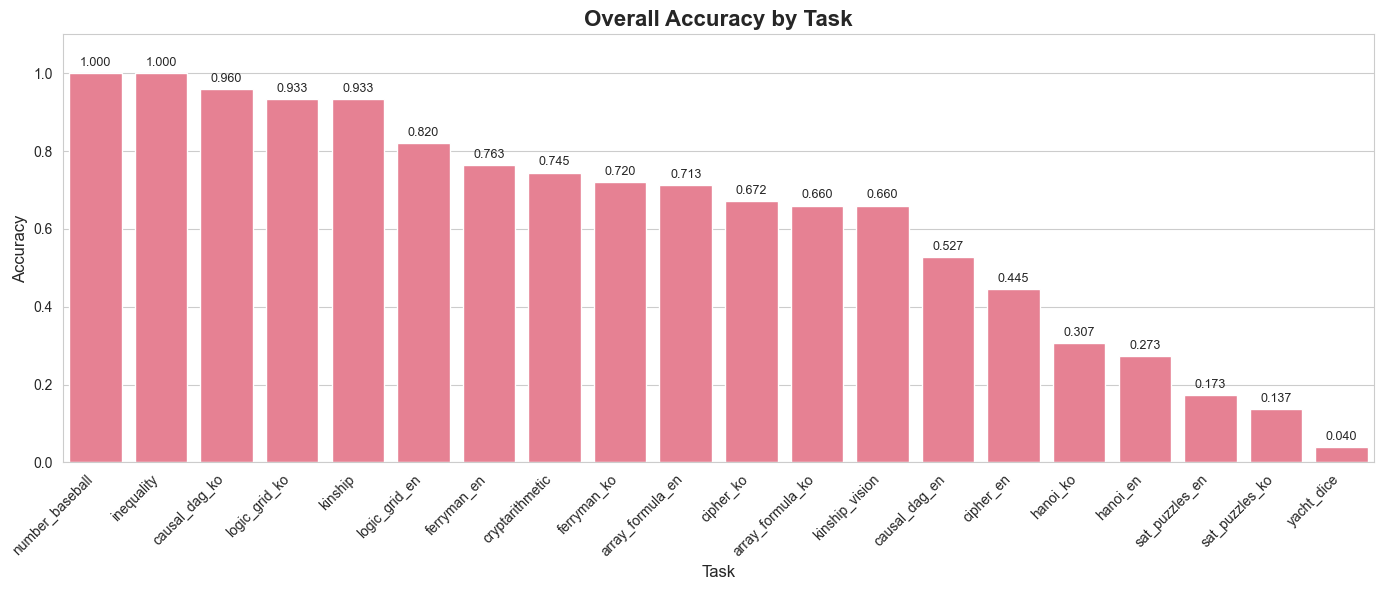

In [4]:
plt.figure(figsize=(14, 6))
task_order = df_overall.groupby('task')['accuracy'].mean().sort_values(ascending=False).index
ax = sns.barplot(data=df_overall, x='task', y='accuracy', order=task_order)
plt.title('Overall Accuracy by Task', fontsize=16, fontweight='bold')
plt.xlabel('Task', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## 2. Accuracy by Task and Difficulty (Grouped Bar Chart)

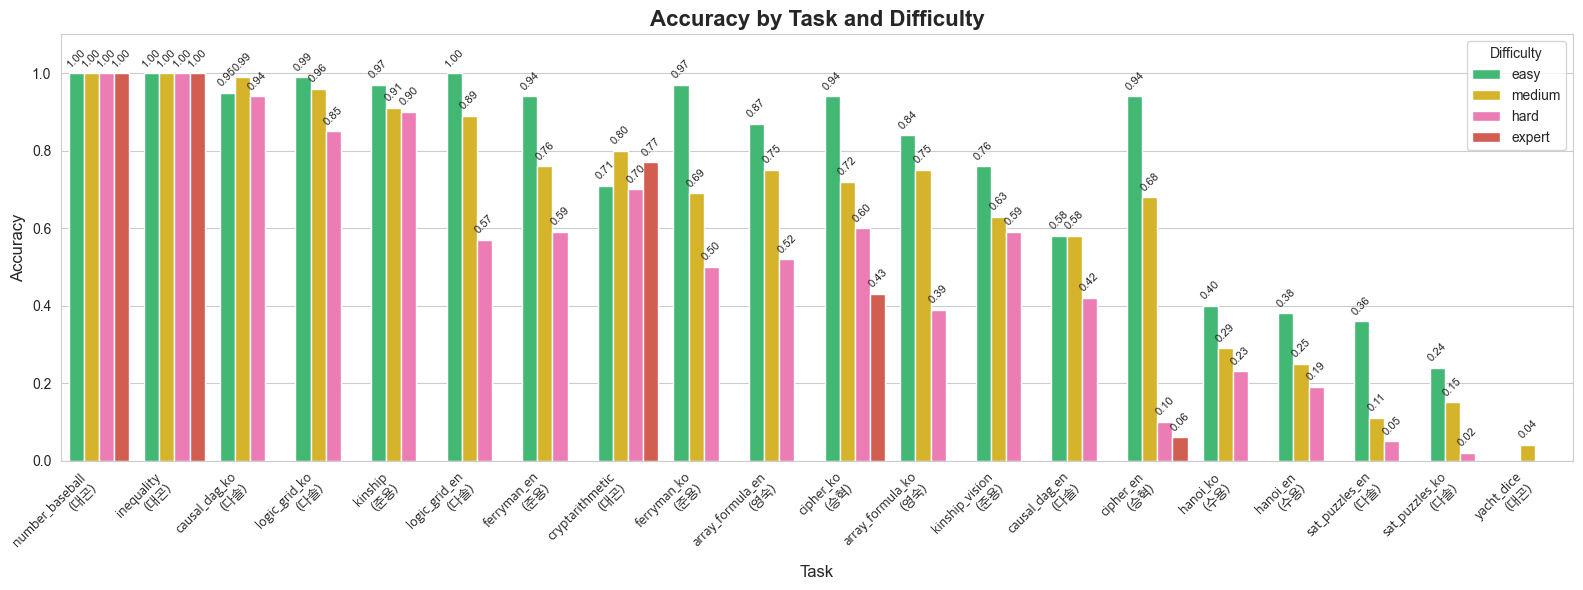

In [5]:
TASK_OWNERS = {
    'array_formula_en': '영숙',
    'array_formula_ko': '영숙',
    'causal_dag_en': '다솔',
    'causal_dag_ko': '다솔',
    'cipher_en': '승혁',
    'cipher_ko': '승혁',
    'cryptarithmetic_en': '대곤',
    'cryptarithmetic_ko': '대곤',
    'ferryman_en': '준용',
    'ferryman_ko': '준용',
    'hanoi_en': '수용',
    'hanoi_ko': '수용',
    'inequality_en': '대곤',
    'inequality_ko': '대곤',
    'kinship': '준용',
    'kinship_vision': '준용',
    'logic_grid_en': '다솔',
    'logic_grid_ko': '다솔',
    'minesweeper_en': '대곤',
    'minesweeper_ko': '대곤',
    'number_baseball_en': '대곤',
    'number_baseball_ko': '대곤',
    'sat_puzzles_en': '다솔',
    'sat_puzzles_ko': '다솔',
    'sudoku_en': '대곤',
    'sudoku_ko': '대곤',
    'yacht_dice_en': '대곤',
    'yacht_dice_ko': '대곤',
}

if len(df_by_difficulty) > 0:
    plt.figure(figsize=(16, 6))
    difficulty_order = ['easy', 'medium', 'hard', 'expert']
    available_difficulties = [d for d in difficulty_order if d in df_by_difficulty['difficulty'].values]
    
    if available_difficulties:
        # Color palette: easy=green, medium=yellow, hard=pink, expert=red
        difficulty_colors = {
            'easy': '#2ecc71',      # Green
            'medium': '#f1c40f',    # Yellow
            'hard': '#ff69b4',     # Pink
            'expert': '#e74c3c'    # Red
        }
        palette = [difficulty_colors.get(d, '#3498db') for d in available_difficulties]
        
        task_order = df_overall.groupby('task')['accuracy'].mean().sort_values(ascending=False).index
        ax = sns.barplot(data=df_by_difficulty, x='task', y='accuracy', hue='difficulty', 
                   hue_order=available_difficulties, order=task_order, palette=palette)
        plt.title('Accuracy by Task and Difficulty', fontsize=16, fontweight='bold')
        plt.xlabel('Task', fontsize=12)
        plt.ylabel('Accuracy', fontsize=12)
        plt.ylim(0, 1.1)
        plt.legend(title='Difficulty', loc='upper right')
        
        # Set x-tick labels with owner names in parentheses
        tick_labels = [f"{t}\n({TASK_OWNERS[t]})" if t in TASK_OWNERS else t for t in task_order]

        # Use FontProperties with direct font file path to reliably render Korean
        korean_font_path = next(
            (f.fname for f in fm.fontManager.ttflist
             if f.name in ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'NanumBarunGothic']),
            None
        )
        fp = fm.FontProperties(fname=korean_font_path) if korean_font_path else None

        from matplotlib.ticker import FixedLocator
        ax.xaxis.set_major_locator(FixedLocator(range(len(task_order))))
        if fp:
            ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontproperties=fp)
        else:
            ax.set_xticklabels(tick_labels, rotation=45, ha='right')
        
        # Add value labels on bars (diagonal on top of bars to avoid overlap)
        for container in ax.containers:
            # Show all labels
            labels = [f'{val:.2f}' for val in container.datavalues]
            # bar_label doesn't support 'ha', so we use rotation only
            ax.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=8, rotation=45)
        
        plt.tight_layout()
        plt.show()
else:
    print("No difficulty-specific data available.")

## 3. Accuracy Heatmap by Task and Difficulty

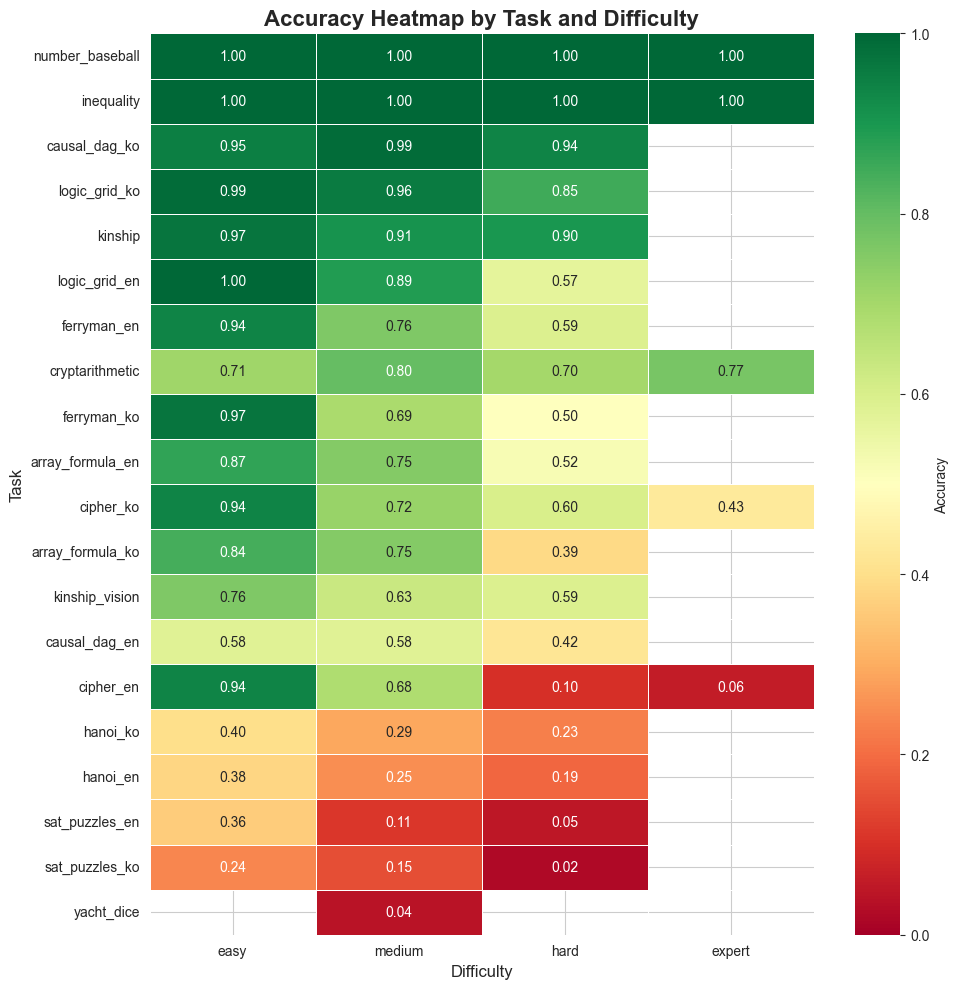

In [6]:
if len(df_by_difficulty) > 0:
    pivot_data = df_by_difficulty.pivot_table(
        values='accuracy', 
        index='task', 
        columns='difficulty', 
        aggfunc='mean'
    )
    
    # Reorder columns by difficulty (easy -> medium -> hard -> expert)
    difficulty_order = ['easy', 'medium', 'hard', 'expert']
    existing_difficulties = [d for d in difficulty_order if d in pivot_data.columns]
    pivot_data = pivot_data[existing_difficulties]
    
    task_order = df_overall.groupby('task')['accuracy'].mean().sort_values(ascending=False).index
    pivot_data = pivot_data.reindex(task_order)
    
    plt.figure(figsize=(10, max(6, len(pivot_data) * 0.5)))
    sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn', 
                vmin=0, vmax=1, cbar_kws={'label': 'Accuracy'}, linewidths=0.5)
    plt.title('Accuracy Heatmap by Task and Difficulty', fontsize=16, fontweight='bold')
    plt.xlabel('Difficulty', fontsize=12)
    plt.ylabel('Task', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No difficulty-specific data available.")

## 4. Average Latency by Task

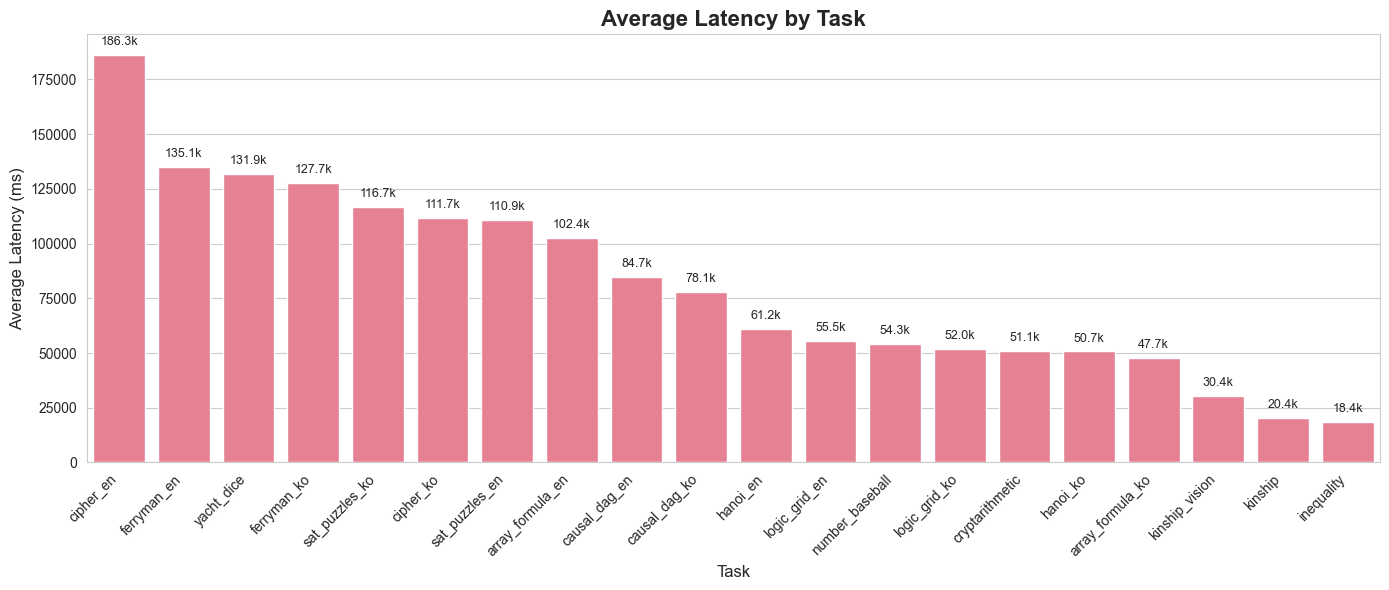

In [7]:
# Average latency by task
plt.figure(figsize=(14, 6))
task_order = df_overall.groupby('task')['avg_latency_ms'].mean().sort_values(ascending=False).index
ax = sns.barplot(data=df_overall, x='task', y='avg_latency_ms', order=task_order)
plt.title('Average Latency by Task', fontsize=16, fontweight='bold')
plt.xlabel('Task', fontsize=12)
plt.ylabel('Average Latency (ms)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars (format as thousands with 'k' suffix for readability)
for container in ax.containers:
    labels = []
    for val in container.datavalues:
        if val >= 1000:
            labels.append(f'{val/1000:.1f}k')
        else:
            labels.append(f'{val:.0f}')
    # Use 'edge' with top padding to place labels above bars
    ax.bar_label(container, labels=labels, label_type='edge', padding=5, fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

## 5. Accuracy vs Latency Scatter Plot

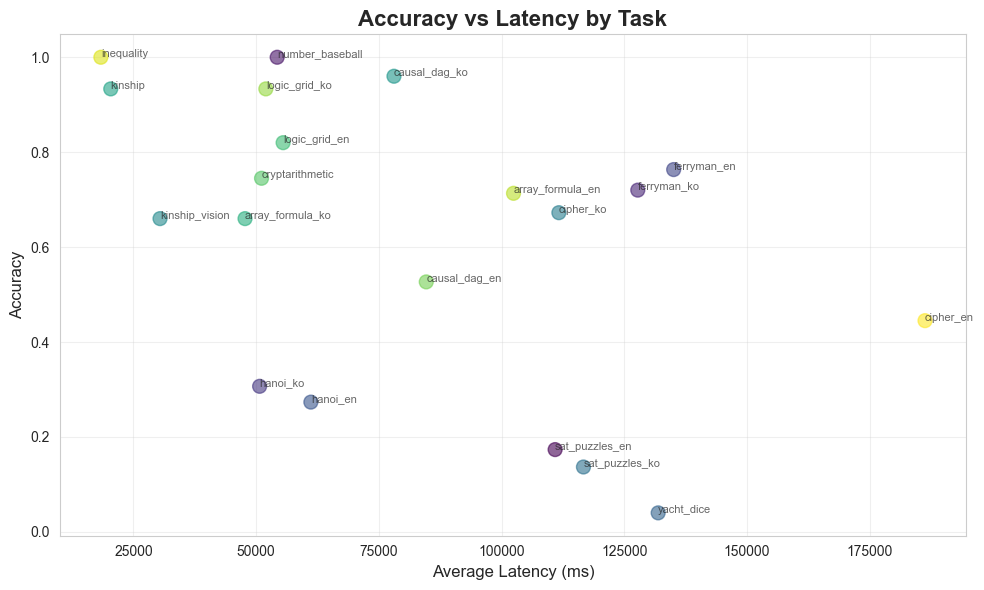

In [8]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_overall['avg_latency_ms'], df_overall['accuracy'], 
                     s=100, alpha=0.6, c=range(len(df_overall)), cmap='viridis')
for i, row in df_overall.iterrows():
    plt.annotate(row['task'], (row['avg_latency_ms'], row['accuracy']), 
                fontsize=8, alpha=0.7)
plt.xlabel('Average Latency (ms)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Latency by Task', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## View detailed data

In [9]:
# Overall data preview
print("Overall Data Preview:")
print(df_overall[['task', 'model', 'accuracy', 'avg_latency_ms', 'total_count']].to_string())

# Task-specific detailed information
if len(df_overall) > 0:
    print("\n\nTask-specific Details:")
    for task in sorted(df_overall['task'].unique()):
        task_data = df_overall[df_overall['task'] == task]
        print(f"\n{task}:")
        print(f"  Accuracy: {task_data['accuracy'].mean():.3f} (std: {task_data['accuracy'].std():.3f})")
        print(f"  Latency: {task_data['avg_latency_ms'].mean():.1f}ms (std: {task_data['avg_latency_ms'].std():.1f}ms)")
        print(f"  Total puzzles: {task_data['total_count'].sum()}")
        
# Difficulty-specific summary
if len(df_by_difficulty) > 0:
    print("\n\nDifficulty-specific Summary:")
    print(df_by_difficulty.groupby(['task', 'difficulty'])[['accuracy', 'correct_count', 'total_count']].first().to_string())

Overall Data Preview:
                task                          model  accuracy  avg_latency_ms  total_count
0     sat_puzzles_en  gemini_gemini-3-flash-preview  0.173333   110909.854301          300
4    number_baseball  gemini_gemini-3-flash-preview  1.000000    54288.655258          400
9        ferryman_ko  gemini_gemini-3-flash-preview  0.720000   127746.878676          300
13          hanoi_ko  gemini_gemini-3-flash-preview  0.306667    50711.464578          300
17       ferryman_en  gemini_gemini-3-flash-preview  0.763333   135057.194854          300
21          hanoi_en  gemini_gemini-3-flash-preview  0.273333    61151.327718          300
25        yacht_dice_en  gemini_gemini-3-flash-preview  0.040000   131899.316583          100
27    sat_puzzles_ko  gemini_gemini-3-flash-preview  0.136667   116679.282146          300
31         cipher_ko  gemini_gemini-3-flash-preview  0.672500   111672.383548          400
36    kinship_vision  gemini_gemini-3-flash-preview  0.660000    